In [55]:
from typing import Sequence
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sim_ranking as sr
import ml_tools as mlt
import spatial_hazard as sh
import sha_calc as sha

In [2]:
def sum_result_df(df: pd.DataFrame, group_keys=Sequence[str]):
    ims = sr.constants.PSA_KEYS
    prob_cols = mlt.array_utils.numpy_str_join("_", ims, "prob")
    misfit_cols = mlt.array_utils.numpy_str_join("_", ims, "misfit")
    weight_cols = mlt.array_utils.numpy_str_join("_", ims, "site_weights")

    result_df = pd.DataFrame(
        data=df[prob_cols].values * df[misfit_cols].values,
        index=df.index,
        columns=misfit_cols,
    )
    result_df[group_keys] = df[group_keys]
    result_df = result_df.groupby(group_keys, observed=True).mean()

    if weight_cols[0] in df.columns:
        result_df[weight_cols] = df.groupby(group_keys, observed=True)[weight_cols].first()

    return result_df.reset_index()

In [53]:
result_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0403_1959_ind_model_loth_baker_corrs")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")

In [4]:
# Load the data
train_sample_df = pd.read_parquet(result_dir / "train_sample_results.parquet")
train_sample_df = sum_result_df(train_sample_df, ["event_id", "site_int", "site_obs"])

val_sample_df = pd.read_parquet(result_dir / "val_sample_results.parquet")
val_sample_df = sum_result_df(val_sample_df, ["event_id", "site_int", "site_obs"])

train_sc_df = pd.read_parquet(result_dir / "train_scenario_results.parquet")
train_sc_df = sum_result_df(train_sc_df, ["event_id", "site_int"])

val_sc_df = pd.read_parquet(result_dir / "val_scenario_results.parquet")
val_sc_df = sum_result_df(val_sc_df, ["event_id", "site_int"])

In [60]:
db = sr.db.DB(db_ffp)

all_sites = db.get_avail_sites()
station_df = db.get_site_df()

dist_matrix = sh.im_dist.calculate_distance_matrix(all_sites, station_df)

val_sample_df["s2s_dist"] = dist_matrix.values[dist_matrix.index.get_indexer_for(val_sample_df["site_int"].values), dist_matrix.columns.get_indexer_for(val_sample_df["site_obs"].values)]
train_sample_df["s2s_dist"] = dist_matrix.values[dist_matrix.index.get_indexer_for(train_sample_df["site_int"].values), dist_matrix.columns.get_indexer_for(train_sample_df["site_obs"].values)]

for cur_im in sr.constants.PSA_KEYS:
	val_sample_df[f"{cur_im}_site_corr"] = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, val_sample_df["s2s_dist"].values)
	train_sample_df[f"{cur_im}_site_corr"] = sha.loth_baker_corr_model.get_correlations(cur_im, cur_im, train_sample_df["s2s_dist"].values)
	

In [41]:
# Config
# ims = ["pSA_0.01", "pSA_0.05", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_5.0"]
ims = ["pSA_1.0"]

In [8]:
print(train_sample_df.shape)
print(val_sample_df.shape)
print("-----------------------")
print(train_sc_df.shape)
print(val_sc_df.shape)

(47154, 65)
(9834, 65)
-----------------------
(3831, 33)
(610, 33)


# Sample Data

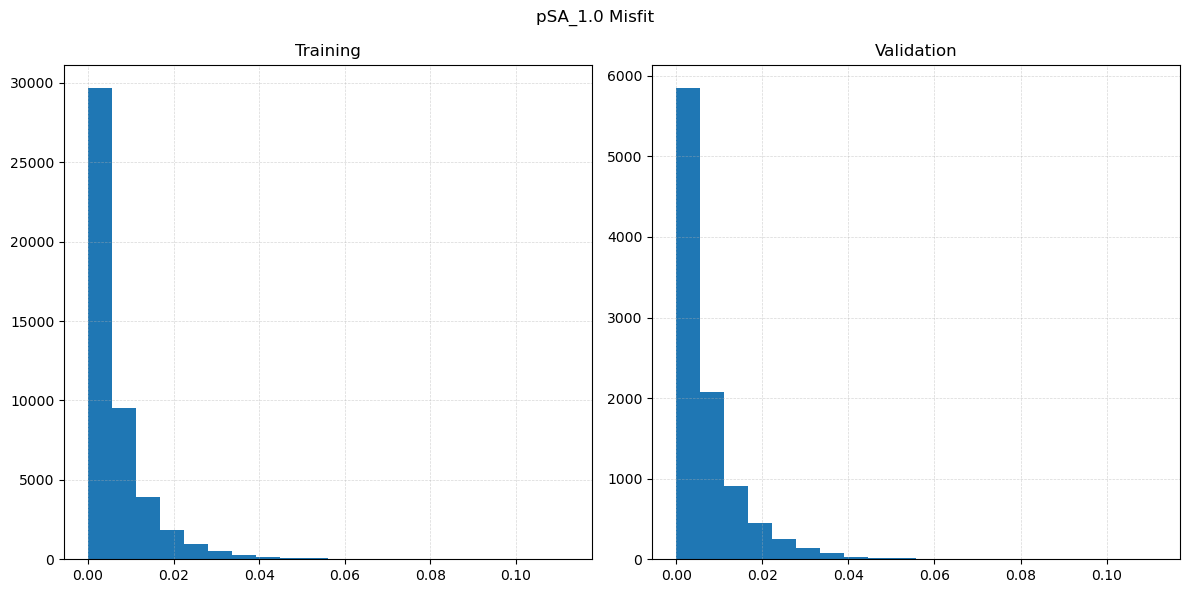

In [42]:
# Plot the misfit distribution
bins = 20

for cur_im in ims:
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	ax1.hist(train_sample_df[f"{cur_im}_misfit"], bins=bins)
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax1.set_title("Training")
	
	ax2.hist(val_sample_df[f"{cur_im}_misfit"], bins=bins)
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax2.set_title("Validation")
	
	fig.suptitle(f"{cur_im} Misfit")
	fig.tight_layout()

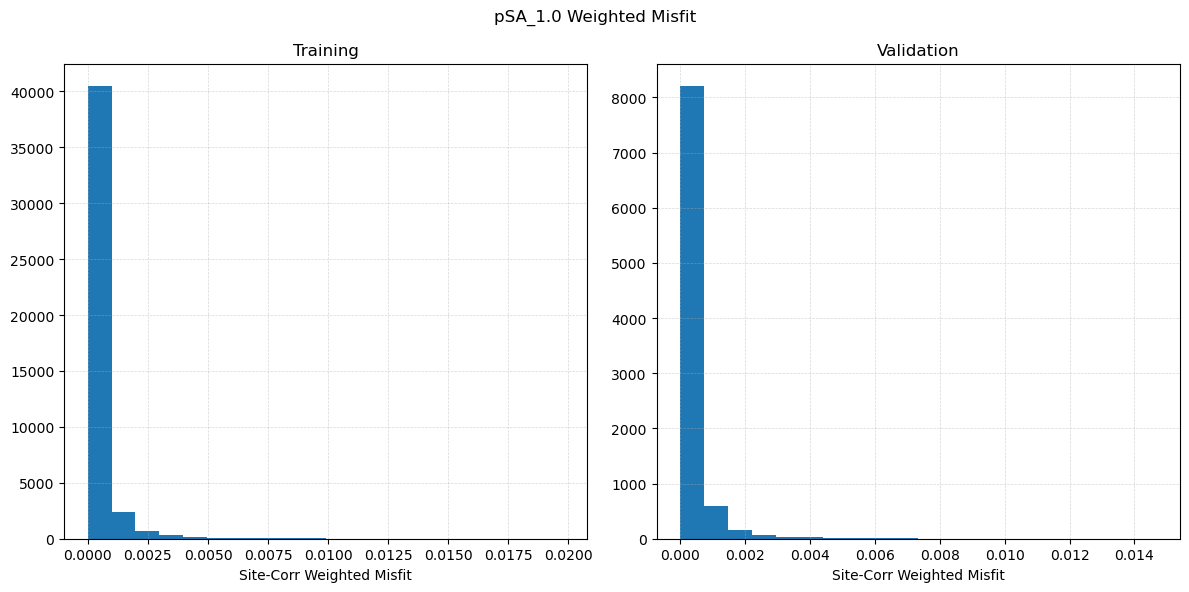

In [43]:
# Weighted Misfit distribution
bins = 20

for cur_im in ims:
	cur_key = f"{cur_im}_misfit"
	train_mask = train_sample_df[cur_key].values < 0.02
	val_mask = val_sample_df[cur_key].values < 0.02
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	ax1.hist(train_sample_df.loc[train_mask, cur_key].values * train_sample_df.loc[train_mask, f"{cur_im}_site_weights"].values, bins=bins)
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax1.set_xlabel("Site-Corr Weighted Misfit")
	ax1.set_title("Training")
	
	ax2.hist(val_sample_df.loc[val_mask, cur_key].values * val_sample_df.loc[val_mask, f"{cur_im}_site_weights"].values, bins=bins)
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax2.set_xlabel("Site-Corr Weighted Misfit")
	ax2.set_title("Validation")
	
	fig.suptitle(f"{cur_im} Weighted Misfit")
	fig.tight_layout()


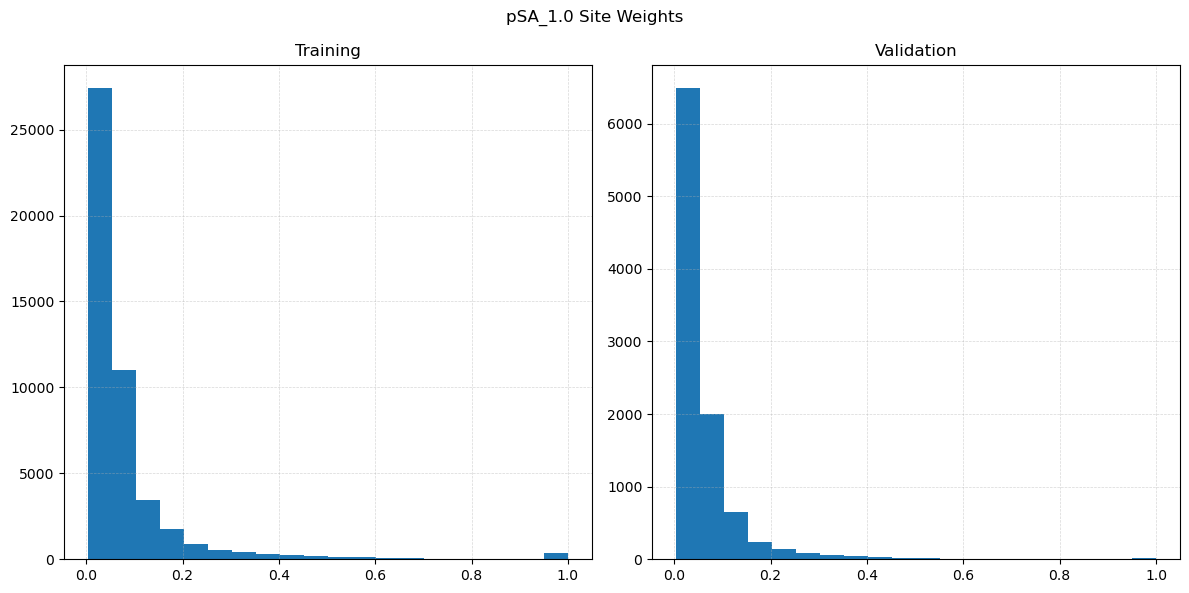

In [44]:
# Plot the site weights distribution
bins = 20

for cur_im in ims:
	cur_key = f"{cur_im}_site_weights"
	train_mask = train_sample_df[cur_key].values < 10
	val_mask = val_sample_df[cur_key].values < 10
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	ax1.hist(train_sample_df.loc[train_mask, cur_key], bins=bins)
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax1.set_title("Training")
	
	ax2.hist(val_sample_df.loc[val_mask, cur_key], bins=bins)
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax2.set_title("Validation")
	
	fig.suptitle(f"{cur_im} Site Weights")
	fig.tight_layout()


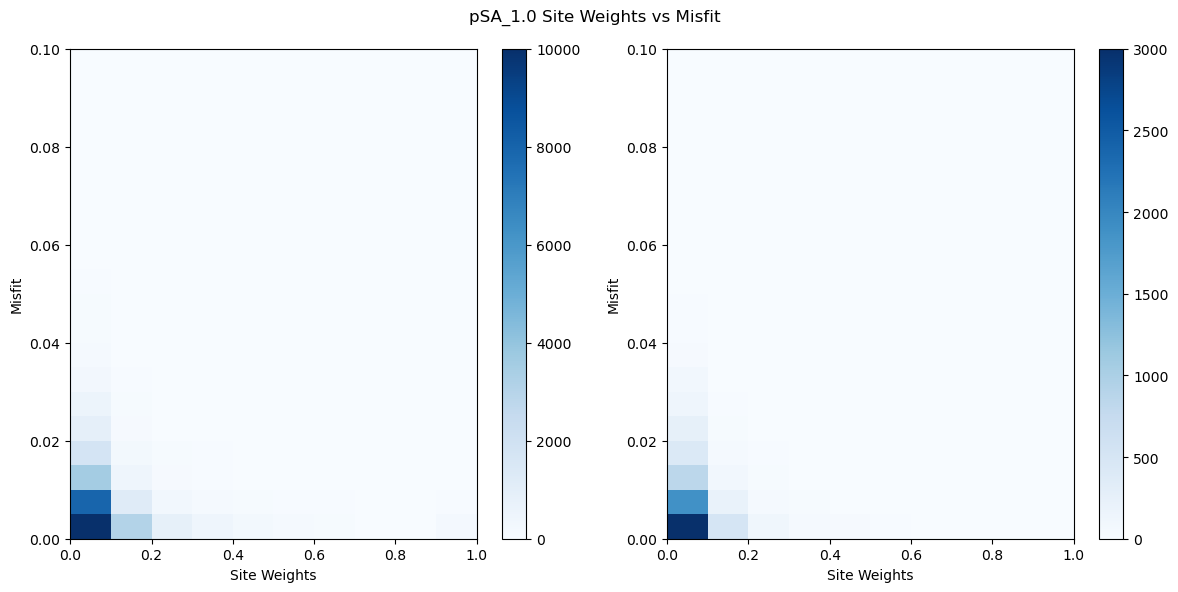

In [45]:
# Plot site weights vs misfit
cmap = "Blues"
hist_range = ((0.0, 1.0), (0.0, 0.1))
bins = (10, 20)

for cur_im in ims:
	train_mask = train_sample_df[f"{cur_im}_misfit"].values < 5
	val_mask = val_sample_df[f"{cur_im}_misfit"].values < 5
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	*_, cm = ax1.hist2d(train_sample_df.loc[train_mask, f"{cur_im}_site_weights"], train_sample_df.loc[train_mask, f"{cur_im}_misfit"], cmap=cmap, vmin=0, vmax=10_000, range=hist_range, bins=bins);
	ax1.set_xlabel("Site Weights")
	ax1.set_ylabel("Misfit")
	fig.colorbar(cm, ax=ax1)
	
	*_, cm = ax2.hist2d(val_sample_df.loc[val_mask, f"{cur_im}_site_weights"], val_sample_df.loc[val_mask, f"{cur_im}_misfit"], cmap=cmap, vmin=0, vmax=3000, range=hist_range, bins=bins);
	ax2.set_xlabel("Site Weights")
	ax2.set_ylabel("Misfit")
	fig.colorbar(cm, ax=ax2)
	
	fig.suptitle(f"{cur_im} Site Weights vs Misfit")
	fig.tight_layout()

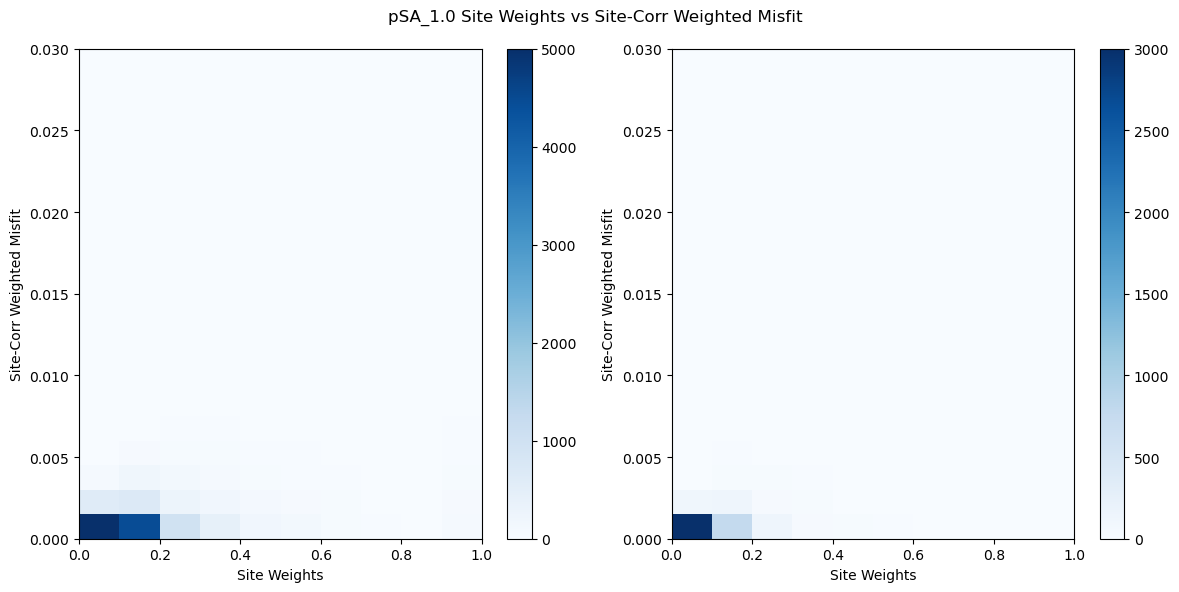

In [47]:
# Plot site weights vs weighted misfit
cmap = "Blues"
hist_range = ((0.0, 1.0), (0.0, 0.03))
bins = (10, 20)

for cur_im in ims:
	train_mask = train_sample_df[f"{cur_im}_misfit"].values < 5
	val_mask = val_sample_df[f"{cur_im}_misfit"].values < 5
	
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	*_, cm = ax1.hist2d(train_sample_df.loc[train_mask, f"{cur_im}_site_weights"], train_sample_df.loc[train_mask, f"{cur_im}_misfit"].values * train_sample_df.loc[train_mask, f"{cur_im}_site_weights"].values, cmap=cmap, vmin=0, vmax=5_000, bins=bins, range=hist_range);
	ax1.set_xlabel("Site Weights")
	ax1.set_ylabel("Site-Corr Weighted Misfit")
	fig.colorbar(cm, ax=ax1)
	
	*_, cm = ax2.hist2d(val_sample_df.loc[val_mask, f"{cur_im}_site_weights"], val_sample_df.loc[val_mask, f"{cur_im}_misfit"].values * val_sample_df.loc[val_mask, f"{cur_im}_site_weights"].values, cmap=cmap, vmin=0, vmax=3000, bins=bins, range=hist_range);
	ax2.set_xlabel("Site Weights")
	ax2.set_ylabel("Site-Corr Weighted Misfit")
	fig.colorbar(cm, ax=ax2)
	
	fig.suptitle(f"{cur_im} Site Weights vs Site-Corr Weighted Misfit")
	fig.tight_layout()

# Scenario Data

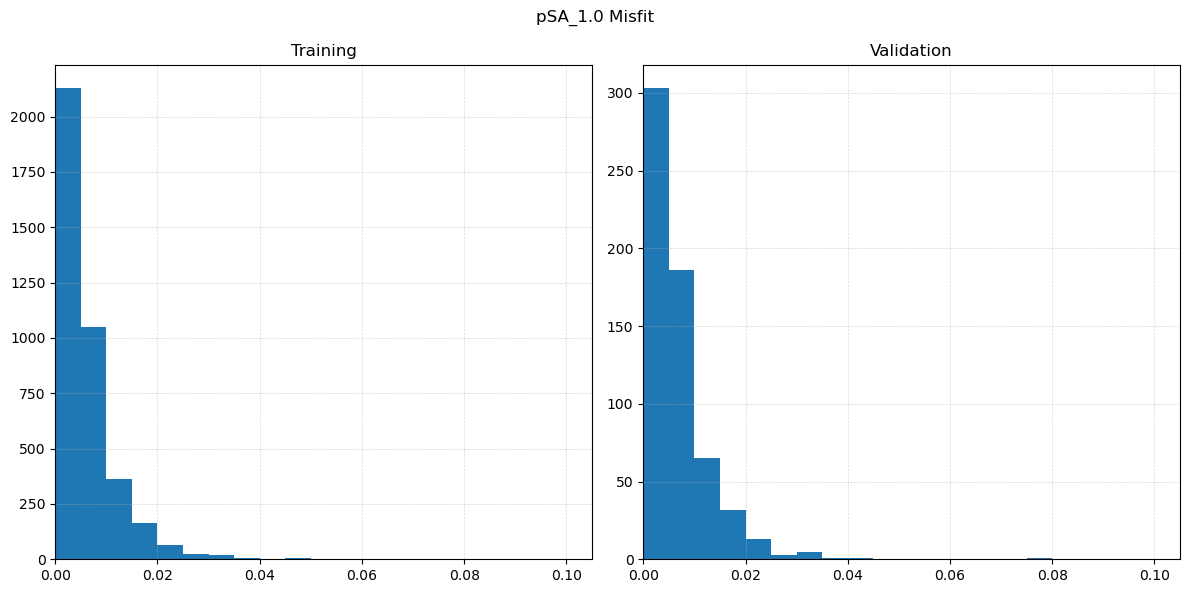

In [48]:
# Plot the loss distribution
bins = 20
range=(0, 0.1)

for cur_im in ims:
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	ax1.hist(train_sc_df[f"{cur_im}_misfit"], bins=bins, range=range)
	ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax1.set_title("Training")
	ax1.set_xlim(0, None)
	
	ax2.hist(val_sc_df[f"{cur_im}_misfit"], bins=bins, range=range)
	ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	ax2.set_title("Validation")
	ax2.set_xlim(0, None)
	
	fig.suptitle(f"{cur_im} Misfit")
	fig.tight_layout()

In [81]:
# Setup
cur_im = "pSA_1.0"

t_group = train_sample_df.sort_values(["event_id", "site_int"]).groupby(["event_id", "site_int"], observed=True)
train_keys = list(t_group.groups.keys())
train_sc_df = train_sc_df.sort_values(["event_id", "site_int"])
assert np.all(np.asarray(train_keys) == train_sc_df[["event_id", "site_int"]].values)

train_n_obs = t_group.size().values
train_min_dist = t_group["s2s_dist"].min().values
train_misfit = train_sc_df[f"{cur_im}_misfit"].values

v_group = val_sample_df.sort_values(["event_id", "site_int"]).groupby(["event_id", "site_int"], observed=True)
val_keys = list(v_group.groups.keys())
val_sc_df = val_sc_df.sort_values(["event_id", "site_int"])
assert np.all(np.asarray(val_keys) == val_sc_df[["event_id", "site_int"]].values)

val_n_obs = v_group.size().values
val_min_dist = v_group["s2s_dist"].min().values
val_misfit = val_sc_df[f"{cur_im}_misfit"].values

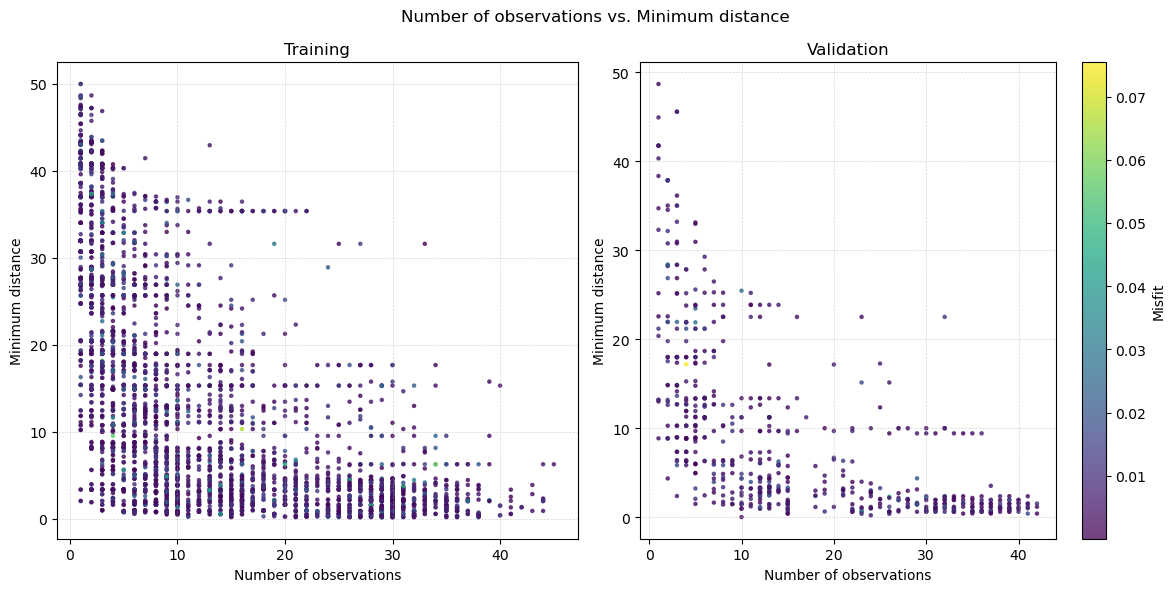

In [82]:
# Number of observations vs. Minimum distance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(train_n_obs, train_min_dist, c=train_misfit, s=5, alpha=0.75)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlabel("Number of observations")
ax1.set_ylabel("Minimum distance")
ax1.set_title("Training")

cm = ax2.scatter(val_n_obs, val_min_dist, c=val_misfit, s=5, alpha=0.75)
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlabel("Number of observations")
ax2.set_ylabel("Minimum distance")
ax2.set_title("Validation")

plt.colorbar(cm, ax=ax2, label="Misfit")


fig.suptitle("Number of observations vs. Minimum distance");
fig.tight_layout()

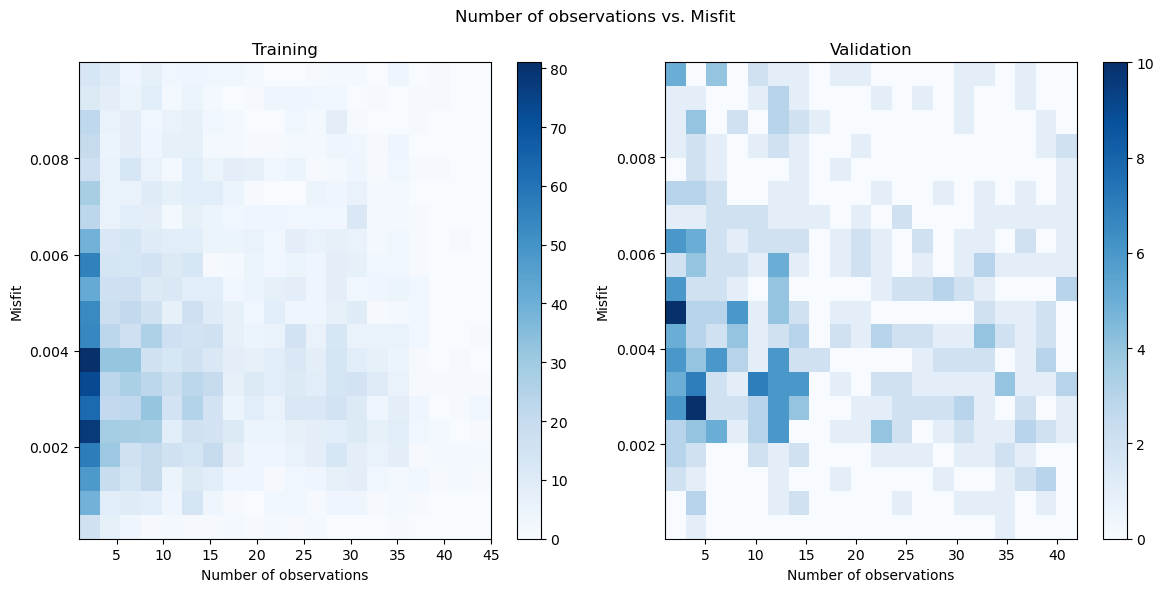

In [100]:
# Plot the number of observations vs. Misfit
cmap = "Blues"
bins = 20

train_mask = train_misfit < 0.01
val_mask = val_misfit < 0.01

for cur_im in ims:
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	*_, cm = ax1.hist2d(train_n_obs[train_mask], train_misfit[train_mask], bins=bins, cmap=cmap)
	ax1.set_xlabel("Number of observations")
	ax1.set_ylabel("Misfit")
	ax1.set_title("Training")
	
	fig.colorbar(cm, ax=ax1)
	
	*_, cm = ax2.hist2d(val_n_obs[val_mask], val_misfit[val_mask], bins=bins, cmap=cmap)
	ax2.set_xlabel("Number of observations")
	ax2.set_ylabel("Misfit")
	ax2.set_title("Validation")
	
	fig.colorbar(cm, ax=ax2)
	
	fig.suptitle("Number of observations vs. Misfit");
	fig.tight_layout()

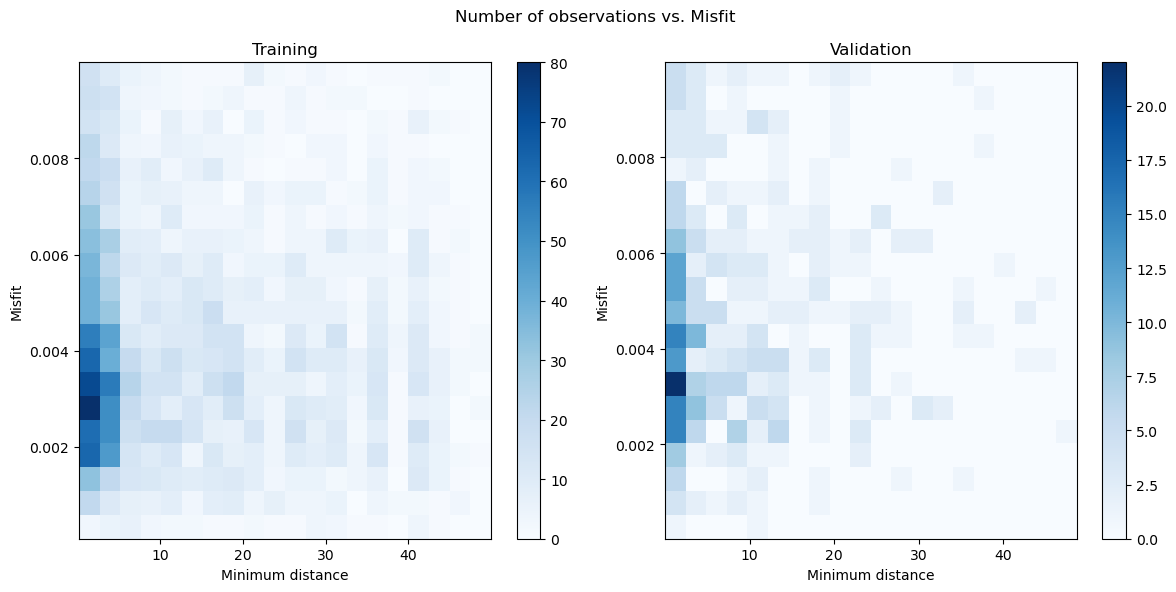

In [101]:
# Plot the Minimum distance vs. Misfit
cmap = "Blues"
bins = 20

train_mask = train_misfit < 0.01
val_mask = val_misfit < 0.01

for cur_im in ims:
	fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
	
	*_, cm = ax1.hist2d(train_min_dist[train_mask], train_misfit[train_mask], bins=bins, cmap=cmap)
	ax1.set_xlabel("Minimum distance")
	ax1.set_ylabel("Misfit")
	ax1.set_title("Training")
	
	fig.colorbar(cm, ax=ax1)
	
	*_, cm = ax2.hist2d(val_min_dist[val_mask], val_misfit[val_mask], bins=bins, cmap=cmap)
	ax2.set_xlabel("Minimum distance")
	ax2.set_ylabel("Misfit")
	ax2.set_title("Validation")
	
	fig.colorbar(cm, ax=ax2)
	
	fig.suptitle("Number of observations vs. Misfit");
	fig.tight_layout()